# MLflow run comparison

This compares the single-GPU run (`93ed1720990a472d898550584fefc046`) with the two-GPU DDP run (`fa00e9580eb040709f05bb5766052b7e`). Both use a global batch size of 32, so compare throughput and final quality directly.

Key measures:
- **Quality:** `test_accuracy_percent`, `test_loss`, and best `val_loss`.
- **Performance:** mean `train_val_seconds` per epoch, total logged epoch time, speedup, and two-GPU scaling efficiency.
- **Memory:** rank-0 peak tensor memory. This is not total memory across both GPUs.

Because `train_val_seconds` includes rank-0 validation, it measures the end-to-end epoch cost of this implementation, not only the training loop.

In [2]:
from pathlib import Path

import mlflow
import pandas as pd
import matplotlib.pyplot as plt

TRACKING_URI = f"sqlite:///{(Path.cwd().parent / 'mlflow.db').as_posix()}"
mlflow.set_tracking_uri(TRACKING_URI)

RUN_IDS = [
    "93ed1720990a472d898550584fefc046",  # 1 GPU, per-GPU batch 32
    "fa00e9580eb040709f05bb5766052b7e",  # 2 GPU, per-GPU batch 16
]

labels = {
    RUN_IDS[0]: "1 GPU / batch 32",
    RUN_IDS[1]: "2 GPU DDP / batch 16",
}

client = mlflow.tracking.MlflowClient()
summary_rows = []
history_rows = []
for run_id in RUN_IDS:
    run = client.get_run(run_id)
    params = run.data.params
    histories = {
        metric: client.get_metric_history(run_id, metric)
        for metric in ["train_loss", "val_loss", "train_val_seconds"]
    }
    epoch_times = [point.value for point in histories["train_val_seconds"]]

    summary_rows.append({
        "run": labels[run_id],
        "world_size": int(params["world_size"]),
        "per_gpu_batch": int(params["per_gpu_batch_size"]),
        "global_batch": int(params["global_batch_size"]),
        "epochs": int(params["epochs"]),
        "test_accuracy_%": run.data.metrics["test_accuracy_percent"],
        "test_loss": run.data.metrics["test_loss"],
        "best_val_loss": run.data.metrics["best_val_loss"],
        "mean_epoch_seconds": sum(epoch_times) / len(epoch_times),
        "total_epoch_seconds": sum(epoch_times),
        "peak_rank0_tensor_memory_mib": run.data.metrics["rank0_peak_tensor_memory_mib"],
    })

    for metric_name in ["train_loss", "val_loss", "train_val_seconds"]:
        for point in histories[metric_name]:
            history_rows.append({
                "run": labels[run_id],
                "epoch": point.step,
                "metric": metric_name,
                "value": point.value,
            })

summary = pd.DataFrame(summary_rows)
history = pd.DataFrame(history_rows)
summary

,run,world_size,per_gpu_batch,global_batch,epochs,test_accuracy_%,test_loss,best_val_loss,mean_epoch_seconds,total_epoch_seconds,peak_rank0_tensor_memory_mib
0,1 GPU / batch 32,1,32,32,30,93.85,0.226053,0.187627,48.125094,1443.752806,380.770508
1,2 GPU DDP / batch 16,2,16,32,30,93.54,0.217831,0.191913,37.773473,1133.204190,314.996094


Epoch-time speedup: 1.274x
Two-GPU scaling efficiency: 63.7%
Logged train/validation throughput: 831 vs 1059 samples/s
Test accuracy change: -0.31 percentage points
Test loss change: -0.0082


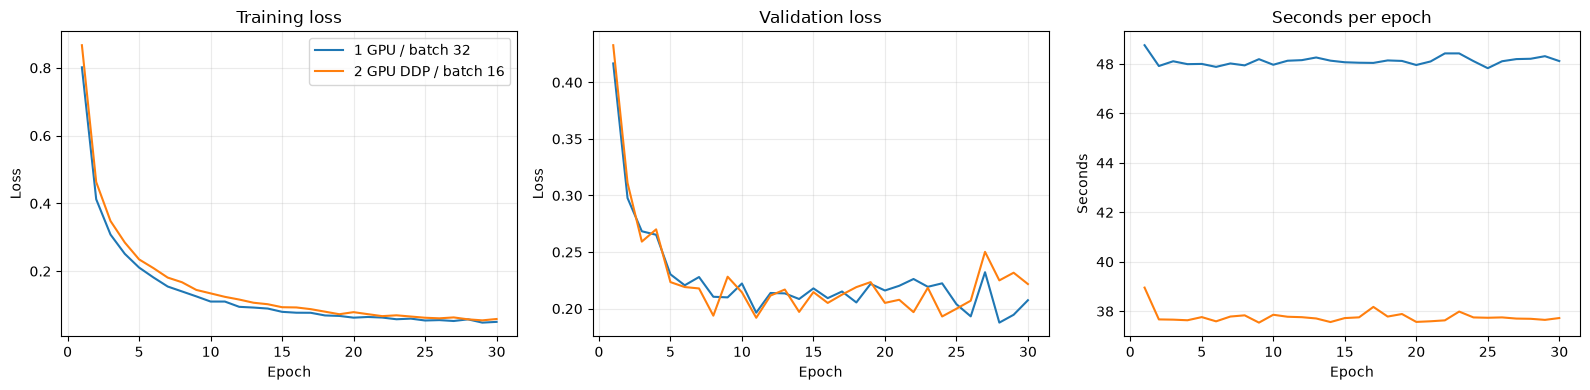

In [3]:
single = summary.loc[summary["world_size"] == 1].iloc[0]
ddp = summary.loc[summary["world_size"] == 2].iloc[0]

speedup = single["total_epoch_seconds"] / ddp["total_epoch_seconds"]
efficiency = speedup / ddp["world_size"]
throughput_single = (50000 * 0.8 * single["epochs"]) / single["total_epoch_seconds"]
throughput_ddp = (50000 * 0.8 * ddp["epochs"]) / ddp["total_epoch_seconds"]

print(f"Epoch-time speedup: {speedup:.3f}x")
print(f"Two-GPU scaling efficiency: {efficiency:.1%}")
print(f"Logged train/validation throughput: {throughput_single:.0f} vs {throughput_ddp:.0f} samples/s")
print(f"Test accuracy change: {ddp['test_accuracy_%'] - single['test_accuracy_%']:+.2f} percentage points")
print(f"Test loss change: {ddp['test_loss'] - single['test_loss']:+.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for label, group in history.groupby("run"):
    for metric, axis, title in [
        ("train_loss", axes[0], "Training loss"),
        ("val_loss", axes[1], "Validation loss"),
        ("train_val_seconds", axes[2], "Seconds per epoch"),
    ]:
        values = group[group["metric"] == metric]
        axis.plot(values["epoch"], values["value"], label=label)
        axis.set_title(title)
        axis.set_xlabel("Epoch")
        axis.grid(alpha=0.25)

axes[0].set_ylabel("Loss")
axes[1].set_ylabel("Loss")
axes[2].set_ylabel("Seconds")
axes[0].legend()
fig.tight_layout()
plt.show()

In [4]:
# Additional derived metrics
single_history = history[history["run"] == single["run"]]
ddp_history = history[history["run"] == ddp["run"]]

def last_value(frame, metric_name):
    values = frame.loc[frame["metric"] == metric_name, "value"]
    return values.iloc[-1]

single_time_saved = single["total_epoch_seconds"] - ddp["total_epoch_seconds"]
time_saved_percent = 100 * single_time_saved / single["total_epoch_seconds"]
throughput_gain_percent = 100 * (throughput_ddp / throughput_single - 1)
memory_reduction_percent = 100 * (
    1 - ddp["peak_rank0_tensor_memory_mib"]
    / single["peak_rank0_tensor_memory_mib"]
)

single_final_train = last_value(single_history, "train_loss")
single_final_val = last_value(single_history, "val_loss")
ddp_final_train = last_value(ddp_history, "train_loss")
ddp_final_val = last_value(ddp_history, "val_loss")

additional_metrics = pd.DataFrame([
    {
        "metric": "Time saved over 30 epochs (seconds)",
        "1 GPU / batch 32": 0,
        "2 GPU DDP / batch 16": single_time_saved,
    },
    {
        "metric": "Time reduction (%)",
        "1 GPU / batch 32": 0,
        "2 GPU DDP / batch 16": time_saved_percent,
    },
    {
        "metric": "Effective throughput gain (%)",
        "1 GPU / batch 32": 0,
        "2 GPU DDP / batch 16": throughput_gain_percent,
    },
    {
        "metric": "Rank-0 tensor memory reduction (%)",
        "1 GPU / batch 32": 0,
        "2 GPU DDP / batch 16": memory_reduction_percent,
    },
    {
        "metric": "Final training loss",
        "1 GPU / batch 32": single_final_train,
        "2 GPU DDP / batch 16": ddp_final_train,
    },
    {
        "metric": "Final validation loss",
        "1 GPU / batch 32": single_final_val,
        "2 GPU DDP / batch 16": ddp_final_val,
    },
    {
        "metric": "Final generalization gap",
        "1 GPU / batch 32": single_final_val - single_final_train,
        "2 GPU DDP / batch 16": ddp_final_val - ddp_final_train,
    },
])

print(f"Time saved over {int(single['epochs'])} epochs: {single_time_saved:.2f} seconds")
print(f"Time reduction: {time_saved_percent:.1f}%")
print(f"Effective throughput gain: {throughput_gain_percent:.1f}%")
print(f"Rank-0 tensor memory reduction: {memory_reduction_percent:.1f}%")
print(f"Single-GPU final generalization gap: {single_final_val - single_final_train:.4f}")
print(f"DDP final generalization gap: {ddp_final_val - ddp_final_train:.4f}")

additional_metrics

Time saved over 30 epochs: 310.55 seconds
Time reduction: 21.5%
Effective throughput gain: 27.4%
Rank-0 tensor memory reduction: 17.3%
Single-GPU final generalization gap: 0.1571
DDP final generalization gap: 0.1629


,metric,1 GPU / batch 32,2 GPU DDP / batch 16
0,Time saved over 30 epochs (seconds),0.000000,310.548617
1,Time reduction (%),0.000000,21.509819
2,Effective throughput gain (%),0.000000,27.404471
3,Rank-0 tensor memory reduction (%),0.000000,17.274031
4,Final training loss,0.050333,0.058809
5,Final validation loss,0.207430,0.221707
6,Final generalization gap,0.157097,0.162898


In [5]:
# Logged GPU system telemetry
system_metric_names = [
    "utilization_percentage",
    "memory_usage_percentage",
    "memory_usage_megabytes",
]
telemetry_rows = []

for run_id in RUN_IDS:
    for gpu_index in [0, 1]:
        row = {
            "run": labels[run_id],
            "gpu": gpu_index,
        }
        for metric_suffix in system_metric_names:
            metric_name = f"system/gpu_{gpu_index}_{metric_suffix}"
            points = client.get_metric_history(run_id, metric_name)
            values = [point.value for point in points]
            if values:
                row[f"{metric_suffix}_mean"] = sum(values) / len(values)
                row[f"{metric_suffix}_peak"] = max(values)
        if len(row) > 2:
            telemetry_rows.append(row)

telemetry = pd.DataFrame(telemetry_rows)
telemetry

,run,gpu,utilization_percentage_mean,utilization_percentage_peak,memory_usage_percentage_mean,memory_usage_percentage_peak,memory_usage_megabytes_mean,memory_usage_megabytes_peak
0,1 GPU / batch 32,0,49.187500,54.0,17.370833,17.4,1489.380556,1491.9
1,1 GPU / batch 32,1,0.000000,0.0,4.800000,4.8,407.800000,407.8
2,2 GPU DDP / batch 16,0,70.371681,85.0,12.069912,12.1,1032.176106,1034.7
3,2 GPU DDP / batch 16,1,99.681416,100.0,11.770796,11.8,1014.676106,1017.2
